In [3]:
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as mp
import os
import astropy.units as u
from astropy.cosmology import Planck18
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck15 as cosmo
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec

/home/elettra/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
with fits.open('SDSS_EnvCatalogue.fits') as hdul:
    data = hdul[1].data
    ra = data.field('Ra') #position of galaxy: radius
    dec = data.field('Dec')  #position of galaxy: degrees 
    redshift = data.field('redshift') 
    loc_dens = data.field('dens_05') 
    lmass = data.field('mass') #log10 of stellar mass
    up = data.field('up') #photometry in filter u
    g = data.field('gp') #photometry in filter g 
    r = data.field('rp')
    i = data.field('ip')
    z = data.field('zp')

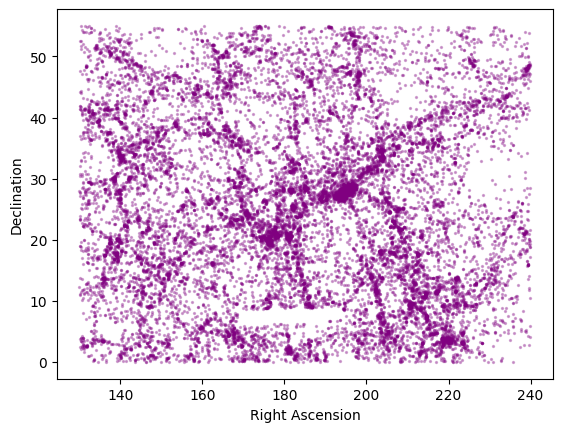

In [5]:
#Task 1: plot the distribution

mp.scatter(ra, dec, s=2, alpha=0.3, color="purple")
mp.xlabel(r'Right Ascension')
mp.ylabel(r'Declination')
#mp.grid(True)
mp.show()

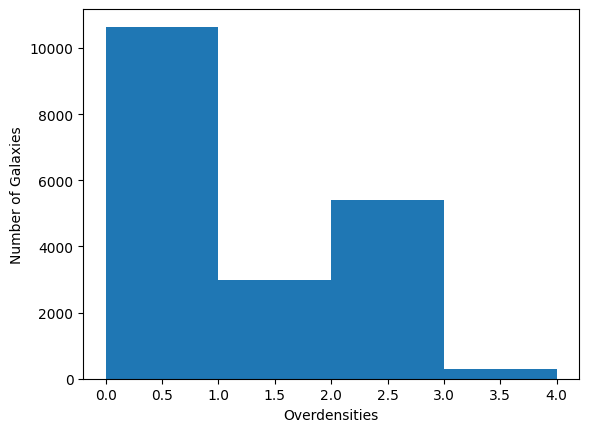

In [6]:
ra1, ra2 = np.min(ra), np.max(ra)
dec1, dec2 = np.min(dec), np.max(dec)

ra1, ra2 = np.radians([ra1, ra2]) #converto ra1, ra2, dec1, dec2 in radianti
dec1, dec2 = np.radians([dec1, dec2])

omega = (ra2 - ra1) * (np.sin(dec2) - np.sin(dec1))  # area solida in steradianti

V_survey = omega * (cosmo.comoving_volume(np.max(redshift)).value 
                   - cosmo.comoving_volume(np.min(redshift)).value) / (4*np.pi) # Volume comovente Mpc^3

R = 0.5 # Mpc
d = (2000 / 70) * u.km # = v / H0 = 2000 km/s / 70 s^-1 (2000 da cilindro +-1000 km/s) --> in km!!

V_cyl = np.pi * R**2 * d.to(u.Mpc)

mean_dens = np.size(lmass) * V_cyl/V_survey
delta = loc_dens*V_cyl / mean_dens
overdensity = np.log10(1 + delta)

bins = np.arange(np.floor(overdensity.min()), np.ceil(overdensity.max()) + 1, 1)

mp.hist(overdensity, bins = bins)
mp.xlabel(r'Overdensities')
mp.ylabel(r'Number of Galaxies')
mp.show()

In [7]:
u_g = up - g
u_r = up - r
u_i = up - i
u_z = up - z

g_u = g - up
g_r = g - r
g_i = g - i
g_z = g - z

r_u = r - up
r_g = r - g
r_i = r - i
r_z = r - z

i_u = i - up
i_g = i - g
i_r = i - r
i_z = i - z

z_u = z - up
z_g = z - g
z_r = z - r
z_i = z - i

In [8]:
counts, bin_edges = np.histogram(overdensity, bins=bins)
mask1 = (overdensity >= bin_edges[0]) & (overdensity <= bin_edges[1])
mask2 = (overdensity >= bin_edges[1]) & (overdensity <= bin_edges[2])
mask3 = (overdensity >= bin_edges[2]) & (overdensity <= bin_edges[3])
mask4 = (overdensity >= bin_edges[3]) & (overdensity <= bin_edges[4])

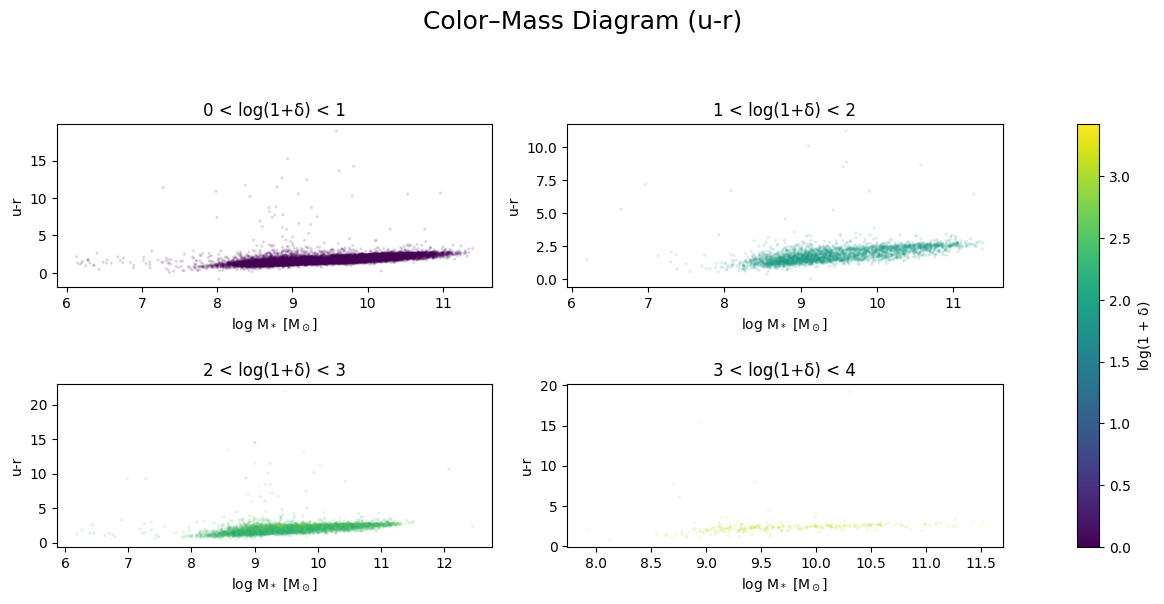

In [9]:
fig = mp.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.05])

fig.suptitle("Color–Mass Diagram (u-r)", fontsize=18, y=1.02)

# limiti comuni della mappa colori
vmin = np.min(overdensity)
vmax = np.max(overdensity)

masks = [mask1, mask2, mask3, mask4]
titles = [
    r'0 < log(1+δ) < 1',
    r'1 < log(1+δ) < 2',
    r'2 < log(1+δ) < 3',
    r'3 < log(1+δ) < 4'
]

axes = []
for i in range(4):
    row = i // 2
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    axes.append(ax)
    
    ax.scatter(
        lmass[masks[i]],
        u_r[masks[i]],
        c=overdensity[masks[i]],
        cmap='viridis',
        s=2,
        alpha=0.1,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(titles[i])
    ax.set_xlabel(r'log M$_*$ [M$_\odot$]')
    ax.set_ylabel(r'u-r')
    #ax.set_ylim(0.9, 1.6)

sm = ScalarMappable(cmap='viridis', norm=mp.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])


cax = fig.add_subplot(gs[:, 2])   # colorbar nella colonna 3 intera
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r'log(1 + $\rm\delta$)')

mp.tight_layout(pad=2)
mp.show()

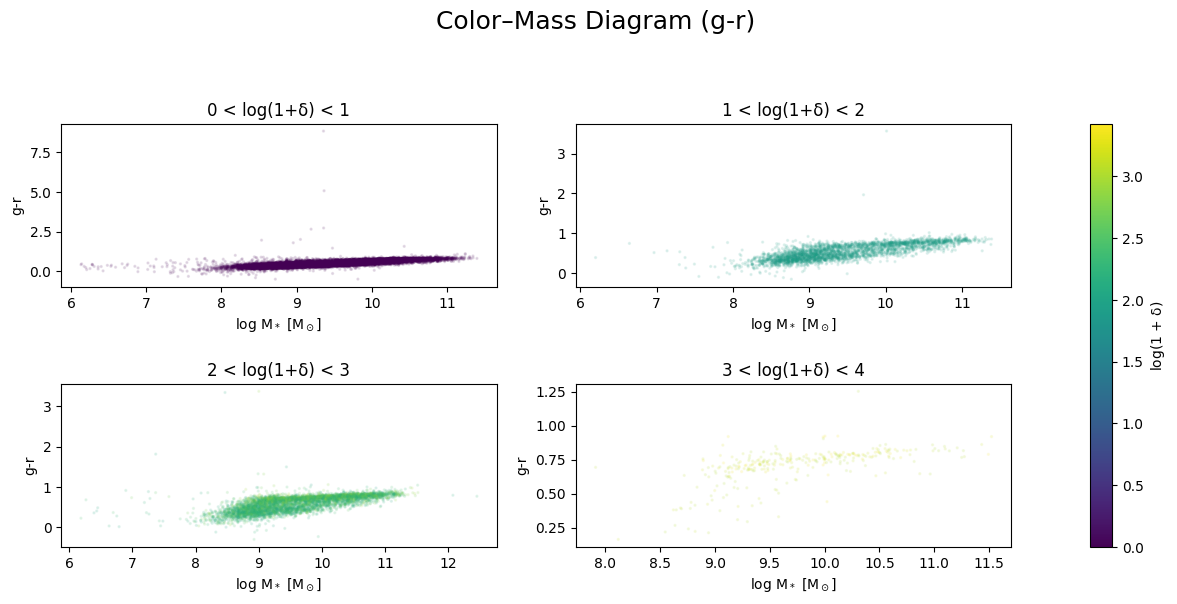

In [10]:
fig = mp.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.05])

fig.suptitle("Color–Mass Diagram (g-r)", fontsize=18, y=1.02)

# limiti comuni della mappa colori
vmin = np.min(overdensity)
vmax = np.max(overdensity)

masks = [mask1, mask2, mask3, mask4]
titles = [
    r'0 < log(1+δ) < 1',
    r'1 < log(1+δ) < 2',
    r'2 < log(1+δ) < 3',
    r'3 < log(1+δ) < 4'
]

axes = []
for i in range(4):
    row = i // 2
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    axes.append(ax)
    
    ax.scatter(
        lmass[masks[i]],
        g_r[masks[i]],
        c=overdensity[masks[i]],
        cmap='viridis',
        s=2,
        alpha=0.1,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(titles[i])
    ax.set_xlabel(r'log M$_*$ [M$_\odot$]')
    ax.set_ylabel(r'g-r')
    #ax.set_ylim(0.9, 1.2)

sm = ScalarMappable(cmap='viridis', norm=mp.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])


cax = fig.add_subplot(gs[:, 2])   # colorbar nella colonna 3 intera
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r'log(1 + $\rm\delta$)')

mp.tight_layout(pad=2)
mp.show()

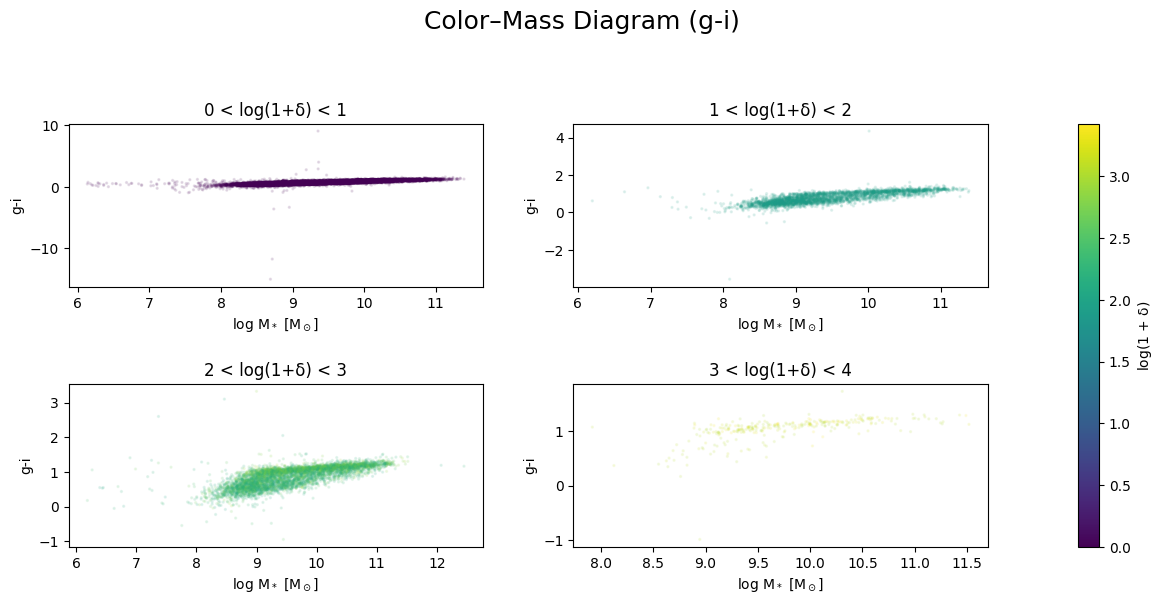

In [11]:
fig = mp.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.05])

fig.suptitle("Color–Mass Diagram (g-i)", fontsize=18, y=1.02)

# limiti comuni della mappa colori
vmin = np.min(overdensity)
vmax = np.max(overdensity)

masks = [mask1, mask2, mask3, mask4]
titles = [
    r'0 < log(1+δ) < 1',
    r'1 < log(1+δ) < 2',
    r'2 < log(1+δ) < 3',
    r'3 < log(1+δ) < 4'
]

axes = []
for i in range(4):
    row = i // 2
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    axes.append(ax)
    
    ax.scatter(
        lmass[masks[i]],
        g_i[masks[i]],
        c=overdensity[masks[i]],
        cmap='viridis',
        s=2,
        alpha=0.1,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(titles[i])
    ax.set_xlabel(r'log M$_*$ [M$_\odot$]')
    ax.set_ylabel(r'g-i')
    #ax.set_ylim(0.9, 1.2)

sm = ScalarMappable(cmap='viridis', norm=mp.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])


cax = fig.add_subplot(gs[:, 2])   # colorbar nella colonna 3 intera
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r'log(1 + $\rm\delta$)')

mp.tight_layout(pad=2)
mp.show()

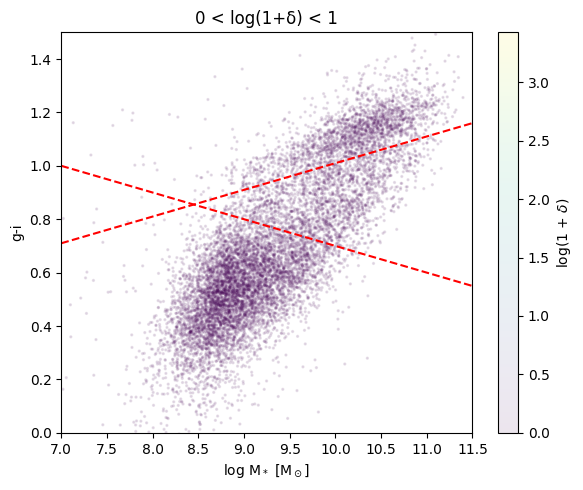

In [12]:
#G-I
i = 0 

fig = mp.figure(figsize=(6,5))

mp.scatter(
    lmass[masks[i]],
    g_i[masks[i]],
    c=overdensity[masks[i]],
    cmap='viridis',
    s=2,
    alpha=0.1,
    vmin=vmin,
    vmax=vmax
)
x = np.linspace(7.0, 11.5, 10)  
#y = 0.1 * x - 0.05 #va bene per due popolazioni di galassie
y1 = 0.1*x + 0.01
y2= -0.1*x + 1.7
mp.plot(x, y1, color='red', linestyle='--')
mp.plot(x, y2, color='red', linestyle='--')
mp.xlabel(r'log M$_*$ [M$_\odot$]')
mp.ylabel('g-i')
mp.xlim(7,11.5)
mp.ylim(0.0, 1.5)
mp.title(titles[i])
mp.colorbar(label=r'log(1 + $\delta$)')

mp.tight_layout()
mp.show()

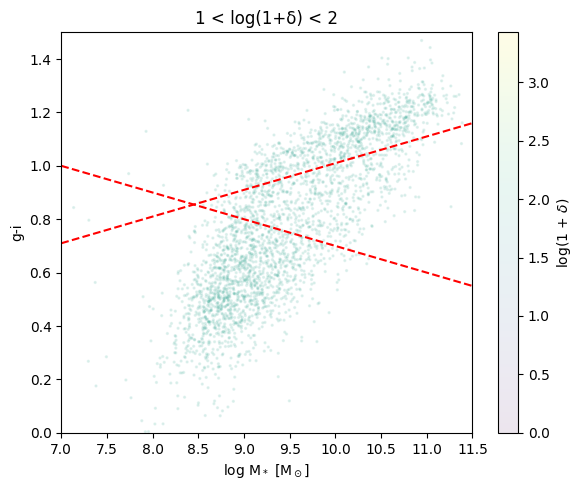

In [13]:
#G-I
i = 1

fig = mp.figure(figsize=(6,5))

mp.scatter(
    lmass[masks[i]],
    g_i[masks[i]],
    c=overdensity[masks[i]],
    cmap='viridis',
    s=2,
    alpha=0.1,
    vmin=vmin,
    vmax=vmax
)
x = np.linspace(7.0, 11.5, 10)  
#y = 0.1 * x - 0.05 #va bene per due popolazioni di galassie
y1 = 0.1*x + 0.01
y2= -0.1*x + 1.7
mp.plot(x, y1, color='red', linestyle='--')
mp.plot(x, y2, color='red', linestyle='--')
mp.xlabel(r'log M$_*$ [M$_\odot$]')
mp.ylabel('g-i')
mp.xlim(7,11.5)
mp.ylim(0.0, 1.5)
mp.title(titles[i])
mp.colorbar(label=r'log(1 + $\delta$)')

mp.tight_layout()
mp.show()

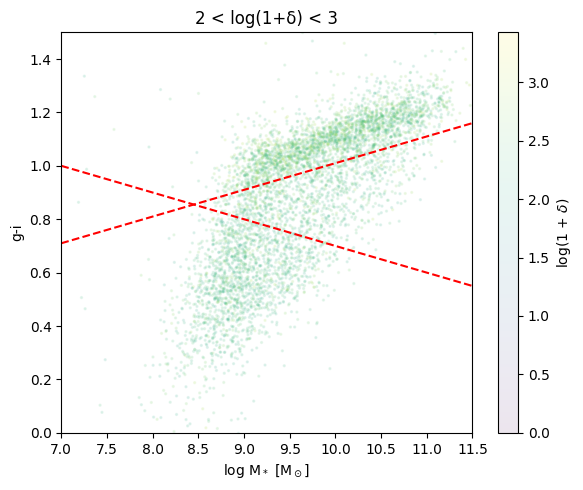

In [14]:
#G-I
i = 2

fig = mp.figure(figsize=(6,5))

mp.scatter(
    lmass[masks[i]],
    g_i[masks[i]],
    c=overdensity[masks[i]],
    cmap='viridis',
    s=2,
    alpha=0.1,
    vmin=vmin,
    vmax=vmax
)
x = np.linspace(7.0, 11.5, 10)  
#y = 0.1 * x - 0.05 #va bene per due popolazioni di galassie
y1 = 0.1*x + 0.01
y2= -0.1*x + 1.7
mp.plot(x, y1, color='red', linestyle='--')
mp.plot(x, y2, color='red', linestyle='--')
mp.xlabel(r'log M$_*$ [M$_\odot$]')
mp.ylabel('g-i')
mp.xlim(7,11.5)
mp.ylim(0.0, 1.5)
mp.title(titles[i])
mp.colorbar(label=r'log(1 + $\delta$)')

mp.tight_layout()
mp.show()

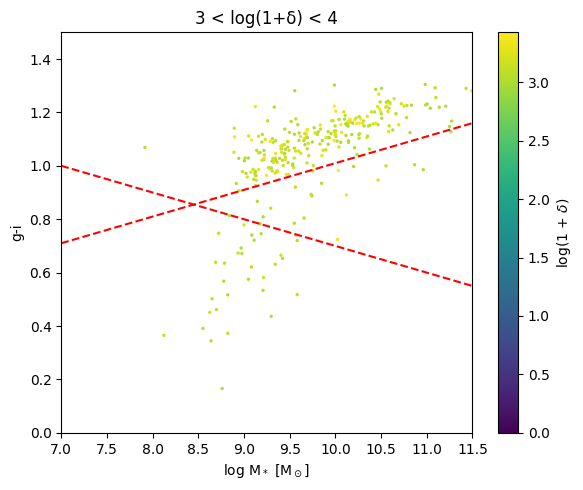

In [15]:
#G-I
i = 3

fig = mp.figure(figsize=(6,5))

mp.scatter(
    lmass[masks[i]],
    g_i[masks[i]],
    c=overdensity[masks[i]],
    cmap='viridis',
    s=2,
    alpha=1,
    vmin=vmin,
    vmax=vmax
)
x = np.linspace(7.0, 11.5, 10)  
#y = 0.1 * x - 0.05 #va bene per due popolazioni di galassie
y1 = 0.1*x + 0.01
y2= -0.1*x + 1.7
mp.plot(x, y1, color='red', linestyle='--')
mp.plot(x, y2, color='red', linestyle='--')
mp.xlabel(r'log M$_*$ [M$_\odot$]')
mp.ylabel('g-i')
mp.xlim(7,11.5)
mp.ylim(0.0, 1.5)
mp.title(titles[i])
mp.colorbar(label=r'log(1 + $\delta$)')

mp.tight_layout()
mp.show()

In [16]:
#y1 = 0.1*x + 0.01
#y2= -0.1*x + 1.7
m1 = 0.1
m2 = -0.1 
q1 = 0.01
q2 = 1.7

mask_above = (g_i > m1*lmass + q1) & (g_i > m2*lmass + q2) #sopra green valley 
mask_between = (g_i < m1*lmass + q1) & (g_i > m2*lmass + q2) #in mezzo alla green valley
mask_below = (g_i < m2*lmass + q2) & (g_i < m2*lmass + q2) #sotto green valley 

#redshift 0 < z < 1
frac_above01 = len(lmass[mask_above & mask1]) /len(lmass[mask1]) 
frac_between01 = len(lmass[mask_between & mask1]) /len(lmass[mask1])
frac_below01 = len(lmass[mask_below & mask1]) / len(lmass[mask1])

#redshift 1 < z < 2
frac_above12 = len(lmass[mask_above & mask2]) /len(lmass[mask2]) 
frac_between12 = len(lmass[mask_between & mask2]) /len(lmass[mask2])
frac_below12 = len(lmass[mask_below & mask2]) / len(lmass[mask2])

#redshift 2 < z < 3
frac_above23 = len(lmass[mask_above & mask3]) /len(lmass[mask3]) 
frac_between23 = len(lmass[mask_between & mask3]) /len(lmass[mask3])
frac_below23 = len(lmass[mask_below & mask3]) / len(lmass[mask3])

#redshift 3 < z < 4
frac_above34 = len(lmass[mask_above & mask4]) /len(lmass[mask4]) 
frac_between34 = len(lmass[mask_between & mask4]) /len(lmass[mask4])
frac_below34 = len(lmass[mask_below & mask4]) / len(lmass[mask4])

print(frac_above01, frac_between01, frac_below01)
print(frac_above12, frac_between12, frac_below12)
print(frac_above23, frac_between23, frac_below23)
print(frac_above34, frac_between34, frac_below34)


0.19280278117072255 0.18538006201259044 0.621817156816687
0.29696363029696365 0.20687354020687354 0.4961628294961628
0.4710987996306556 0.19353647276084948 0.3353647276084949
0.8131487889273357 0.0726643598615917 0.11418685121107267


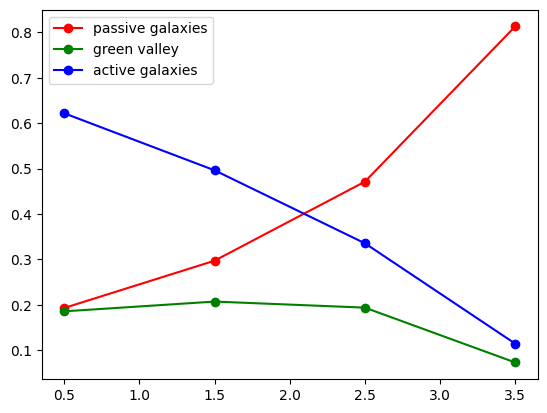

In [17]:
red = [frac_above01, frac_above12, frac_above23, frac_above34]
green = [frac_between01, frac_between12, frac_between23, frac_between34]
blue = [frac_below01, frac_below12, frac_below23, frac_below34]

overdensity = [0.5, 1.5, 2.5, 3.5]

mp.plot(overdensity, red, color = 'red', marker = 'o', label = 'passive galaxies')
mp.plot(overdensity, green, color = 'green', marker = 'o', label = 'green valley')
mp.plot(overdensity, blue, color = 'blue', marker = 'o', label = 'active galaxies')
mp.legend()
mp.show()

In [18]:
#PART 2

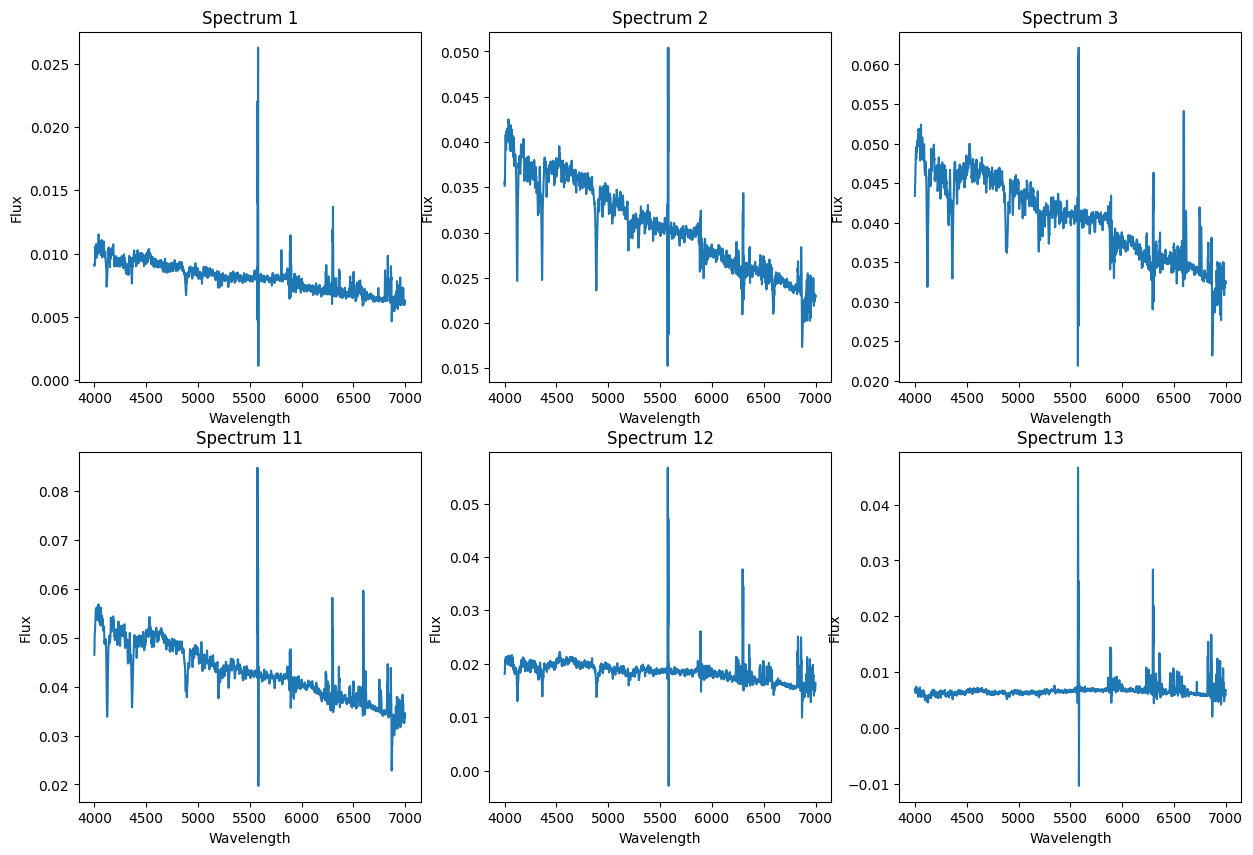

In [19]:
#plot spectra

fig, axes = mp.subplots(2, 3, figsize=(15, 10))
regionids = [1,2,3,11,12,13]

for regionid, ax in zip(regionids, axes.flat): 
    
    spec = fits.open(f'Spec_N4330_region{regionid}.fits')
    #spec = fits.open('Spec_N4330_region1.fits')
    specflx = spec[0].data
    specerr = spec[1].data
    specwav = spec[2].data
    ax.plot(specwav,specflx)
    ax.set_xlabel(f'Wavelength')
    ax.set_ylabel(f'Flux')
    ax.set_title(f'Spectrum {regionid}')

mp.show()


In [20]:
#Task 1 

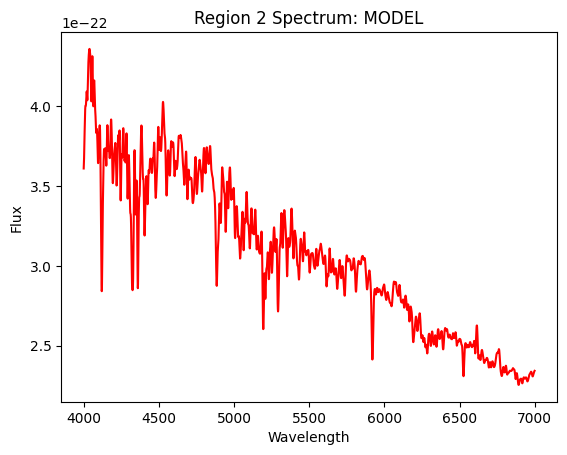

In [21]:
#Read model
regionid = 2
modhdu = fits.open('Models_N4330_region{}.fits'.format(regionid))
#How many extensions
Next = modhdu[0].header['NEXT']
modwave = modhdu[0].data
modwave = modwave.flatten() 

for ext in np.arange(1,Next+1):
    thisext = modhdu[ext]
    thishead = thisext.header
    modspec = thisext.data[0]
    Qtau = thishead['TRUNCTAU']
    Qage = thishead['TRUNCAGE']
    photarr = np.array((thishead['MODFUV'],thishead['MODNUV'],\
    thishead['MODU'],thishead['MODG'],\
    thishead['MODI'],thishead['MODZ'], \
    thishead['MODIR1'],thishead['MODIR4']))

#plot the spectra
    
mp.figure()
#mp.plot(specwav2,specflx2, color = 'blue', label = 'Spectrum')
mp.plot(modwave, modspec, color = 'red', label = 'Model')
mp.title('Region 2 Spectrum: MODEL')
mp.xlabel('Wavelength')
mp.ylabel('Flux')
mp.show()


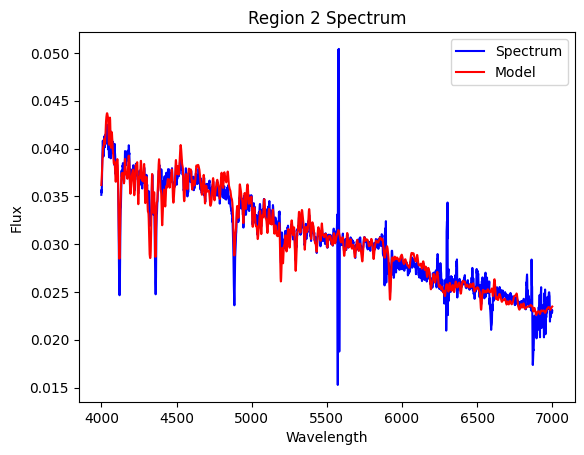

In [22]:
#plot the model and the spectrum on the same graphic

#read spectrum 
regionid = 2
spec2 = fits.open('Spec_N4330_region{}.fits'.format(regionid))

specflx2 = spec2[0].data
specwav2 = spec2[2].data

#Read model
modhdu = fits.open('Models_N4330_region{}.fits'.format(regionid))
#How many extensions
Next = modhdu[0].header['NEXT']
modwave = modhdu[0].data
modwave = modwave.flatten()
for ext in np.arange(1,Next+1):
    thisext = modhdu[ext]
    thishead = thisext.header
    modspec = thisext.data[0]
    modspec_normalized = modspec/np.mean(modspec)*np.mean(specflx2) #normalizzo spettro del modello
    Qtau = thishead['TRUNCTAU']
    Qage = thishead['TRUNCAGE']
    photarr = np.array((thishead['MODFUV'],thishead['MODNUV'],\
    thishead['MODU'],thishead['MODG'],\
    thishead['MODI'],thishead['MODZ'], \
    thishead['MODIR1'],thishead['MODIR4']))
    
#plot the spectra
#modspec_normalized = modspec/np.mean(modspec)*np.mean(specflx2) #normalizzo spettro del modello
mp.figure()
mp.plot(specwav2,specflx2, color = 'blue', label = 'Spectrum')
mp.plot(modwave, modspec_normalized, color = 'red', label = 'Model')
mp.title('Region 2 Spectrum')
mp.xlabel('Wavelength')
mp.ylabel('Flux')
mp.legend()
mp.show()


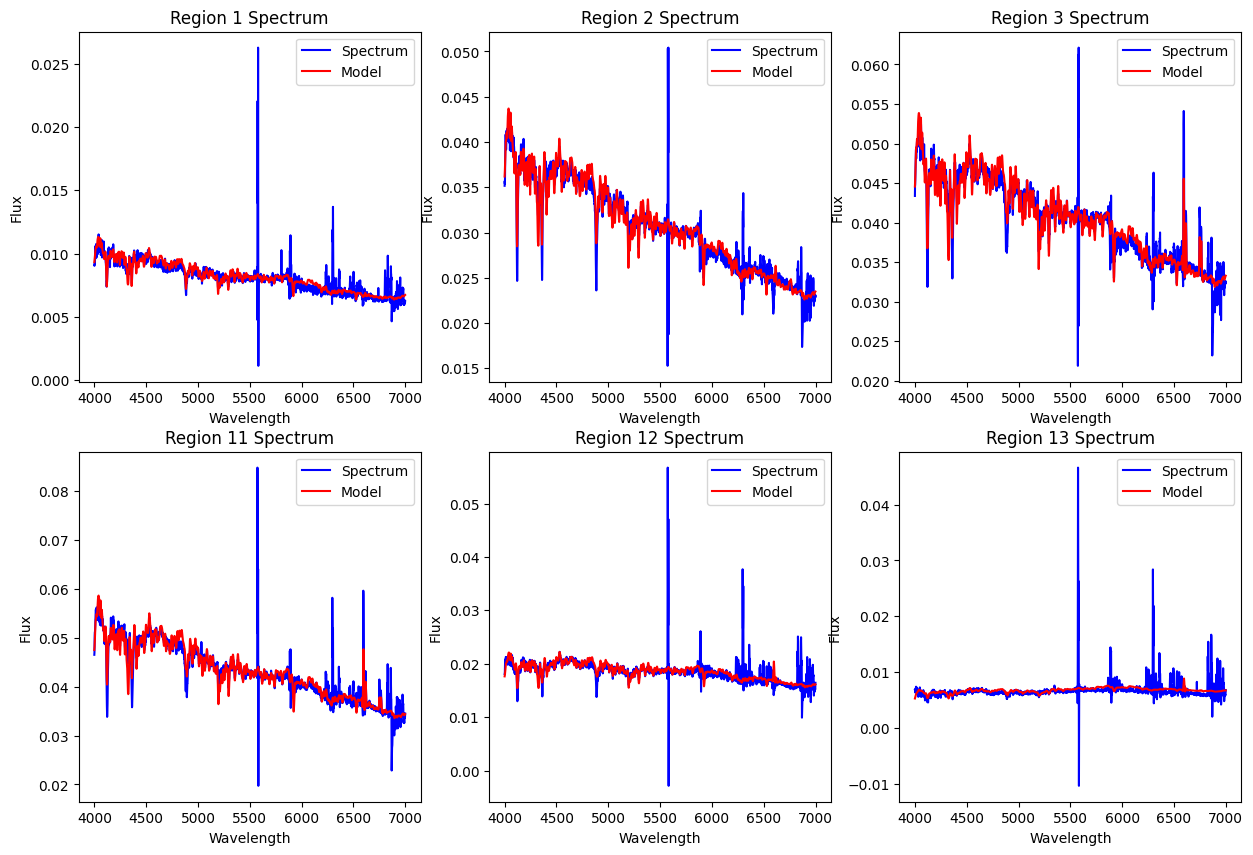

In [23]:
#plot spectra

fig, axes = mp.subplots(2, 3, figsize=(15, 10))
regionids = [1,2,3,11,12,13]

for regionid, ax in zip(regionids, axes.flat): 
    
    spec = fits.open(f'Spec_N4330_region{regionid}.fits')
    specflx = spec[0].data
    specerr = spec[1].data
    specwav = spec[2].data
    
    modhdu = fits.open(f'Models_N4330_region{regionid}.fits')
    #How many extensions
    Next = modhdu[0].header['NEXT']
    modwave = modhdu[0].data
    modwave = modwave.flatten()
    for ext in np.arange(1,Next+1):
        thisext = modhdu[ext]
        thishead = thisext.header
        modspec = thisext.data[0]
        modspec_normalized = modspec/np.mean(modspec)*np.mean(specflx) #normalizzo spettro del modello
        Qtau = thishead['TRUNCTAU']
        Qage = thishead['TRUNCAGE']
        photarr = np.array((thishead['MODFUV'],thishead['MODNUV'],\
        thishead['MODU'],thishead['MODG'],\
        thishead['MODI'],thishead['MODZ'], \
        thishead['MODIR1'],thishead['MODIR4']))

    ax.plot(specwav,specflx, color = 'blue', label = 'Spectrum')
    ax.plot(modwave, modspec_normalized, color = 'red', label = 'Model')
    ax.set_title(f'Region {regionid} Spectrum')
    ax.set_xlabel(f'Wavelength')
    ax.set_ylabel(f'Flux')
    ax.legend()
    
mp.show()

In [24]:
#Task 2


--- ELABORAZIONE REGION 1 ---
  > Trovati 110 modelli da testare nel file FITS...
  > ANALISI COMPLETATA:
  > Modello Vincente (Best Fit): Estensione FITS #64
  > Chi-Quadro Minimo: 3034.47
  > Parametri: Age=500 Myr, Tau=120 Myr

--- ELABORAZIONE REGION 2 ---
  > Trovati 110 modelli da testare nel file FITS...
  > ANALISI COMPLETATA:
  > Modello Vincente (Best Fit): Estensione FITS #3
  > Chi-Quadro Minimo: 2324.69
  > Parametri: Age=100 Myr, Tau=20 Myr

--- ELABORAZIONE REGION 3 ---
  > Trovati 110 modelli da testare nel file FITS...
  > ANALISI COMPLETATA:
  > Modello Vincente (Best Fit): Estensione FITS #28
  > Chi-Quadro Minimo: 2643.51
  > Parametri: Age=200 Myr, Tau=60 Myr

--- ELABORAZIONE REGION 11 ---
  > Trovati 110 modelli da testare nel file FITS...
  > ANALISI COMPLETATA:
  > Modello Vincente (Best Fit): Estensione FITS #2
  > Chi-Quadro Minimo: 5110.19
  > Parametri: Age=75 Myr, Tau=20 Myr

--- ELABORAZIONE REGION 12 ---
  > Trovati 110 modelli da testare nel file FITS.

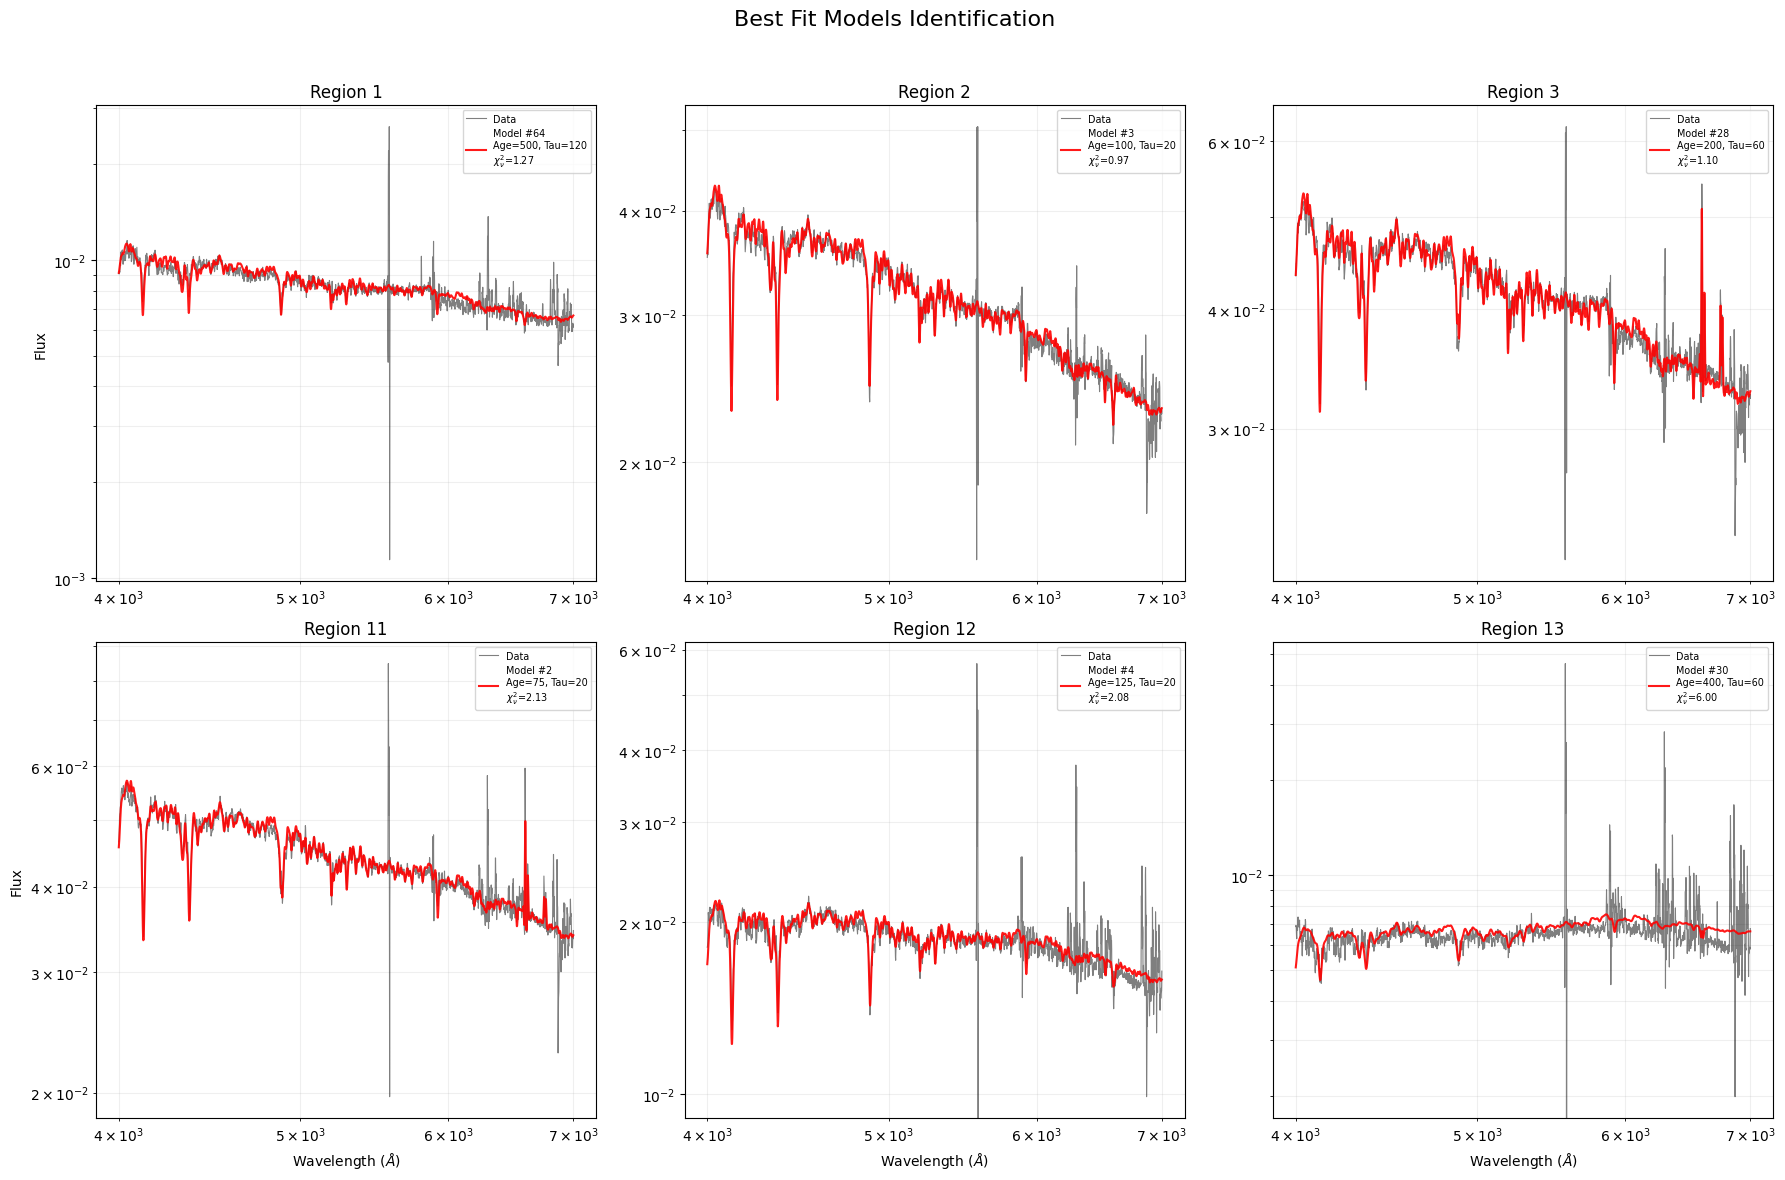

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() #

# Ciclo sulle regioni
regionid = [1,2,3,11,12,13]
for i, ax in enumerate(axes):
    print(f"\n{'='*40}")
    print(f"--- ELABORAZIONE REGION {regionid[i]} ---")
   
    # 1. CARICAMENTO DATI
    file_spec = f'Spec_N4330_region{regionid[i]}.fits'
   
    with fits.open(file_spec) as spec:
        specflx = spec[0].data
        specerr = spec[1].data
        specwav = spec[2].data

    # Maschera per dati validi
    valid_mask = (specerr > 0) & np.isfinite(specerr) & np.isfinite(specflx)
    meanspectra = np.nanmean(specflx[valid_mask])

    # Plot Dati
    ax.plot(specwav, specflx, color='black', alpha=0.5, label='Data', linewidth=0.8)

    # 2. CARICAMENTO MODELLI: ogni estensione continene un modello diverso, ottenuto per un determinato set di parametri (età=truncage, tempo di spegnimento=trunctau)
    file_model = f'Models_N4330_region{regionid[i]}.fits'
   
    # Liste per accumulare i risultati di TUTTI i modelli testati per questa regione
    all_chi2 = []
    all_ages = []
    all_taus = []
    all_models_specs = []

    with fits.open(file_model) as modhdu:
        Next = modhdu[0].header['NEXT']
        modwave = modhdu[0].data.flatten()
       
        print(f"  > Trovati {Next} modelli da testare nel file FITS...")

        # --- IL LOOP SUI MODELLI ---
        # Qui scorre tutti i diversi modelli disponibili per questa regione
        for ext in np.arange(1, Next+1):
            thisext = modhdu[ext]
            modspec_raw = thisext.data[0]
           
            # Parametri modello
            age = thisext.header['TRUNCAGE']
            tau = thisext.header['TRUNCTAU']
           
            # Normalizzazione e Interpolazione
            meanmodel = np.nanmean(modspec_raw)
            if meanmodel == 0:
                # Se il modello è vuoto, salviamo valori fittizi per mantenere l'ordine
                all_chi2.append(np.inf)
                all_ages.append(age)
                all_taus.append(tau)
                all_models_specs.append(modspec_raw)
                continue

            norm_factor = meanspectra / meanmodel
            modspec_scaled = modspec_raw * norm_factor
           
            # Interpolazione sulla griglia dei dati
            modspec_interp = np.interp(specwav, modwave, modspec_scaled)
           
            # Calcolo Chi2 Pesato
            chi_terms = ((specflx[valid_mask] - modspec_interp[valid_mask]) / specerr[valid_mask])**2
            chi2 = np.sum(chi_terms)
           
            # Salvataggio in lista
            all_chi2.append(chi2)
            all_ages.append(age)
            all_taus.append(tau)
            all_models_specs.append(modspec_scaled) # Salviamo lo spettro scalato

    # --- 3. TROVARE IL VINCITORE ---
    all_chi2 = np.array(all_chi2)
   
    # Indice del valore minimo nella lista
    min_idx = np.argmin(all_chi2)
   
    # Calcolo quale estensione FITS era (visto che la lista parte da 0 ma le estensioni da 1)
    best_ext_number = min_idx + 1
   
    min_chi2 = all_chi2[min_idx]
    best_age = all_ages[min_idx]
    best_tau = all_taus[min_idx]
    best_spec_plot = all_models_specs[min_idx]

    # --- STAMPA RISULTATI DETTAGLIATI ---
    print(f"  > ANALISI COMPLETATA:")
    print(f"  > Modello Vincente (Best Fit): Estensione FITS #{best_ext_number}")
    print(f"  > Chi-Quadro Minimo: {min_chi2:.2f}")
    print(f"  > Parametri: Age={best_age:.0f} Myr, Tau={best_tau:.0f} Myr")

    # 4. PLOT DEL VINCITORE
    # Calcolo Chi2 Ridotto per la label
    n_points = np.sum(valid_mask)
    dof = n_points - 2
    red_chi2 = min_chi2 / dof

    label_str = (f'Model #{best_ext_number}\n'
                 f'Age={best_age:.0f}, Tau={best_tau:.0f}\n'
                 f'$\chi^2_\\nu$={red_chi2:.2f}')
                 
    ax.plot(modwave, best_spec_plot, color='red', alpha=0.9, linewidth=1.5, label=label_str)
   
    # Cosmetica
    ax.set_title(f'Region {regionid[i]}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="-", alpha=0.2)
   
    if i >= 3: ax.set_xlabel('Wavelength ($\AA$)')
    if i % 3 == 0: ax.set_ylabel('Flux')
   
    ax.legend(fontsize='x-small', loc='best')

plt.suptitle('Best Fit Models Identification', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

In [ ]:
#Task 3

In [33]:
photo = fits.open(f'Phot_N4330.fits')
table = Table.read(f'Phot_N4330.fits')
print(table)

 id f_FUV  e_FUV  f_NUV e_NUV  f_U  ...  e_Z   f_IRAC1 e_IRAC1 f_IRAC4 e_IRAC4
--- ------ ------ ----- ----- ----- ... ------ ------- ------- ------- -------
  1   0.07 0.0025 0.111 0.005 0.513 ...  0.181   1.329    0.11   0.341   0.197
  2  0.107  0.005 0.171 0.008 0.686 ...   0.11   1.477   0.049   0.598    0.08
  3 0.1229  0.006 0.188 0.009 0.845 ...  0.148   2.452   0.052   3.079   0.085
 11  0.145   0.07 0.219  0.01 0.848 ...  0.131   2.068   0.052   3.326   0.084
 12   0.02 0.0018 0.057 0.003 0.374 ... 0.0814   0.942    0.05   0.298    0.08
 13  0.007  0.002 0.032 0.004 0.323 ...  0.161   0.863   0.122   0.082   0.189


In [37]:
data_table = photo[1].data

flux_FUV = data_table['f_FUV']

err_FUV = data_table['e_FUV']

flux_NUV = data_table['f_NUV']

err_NUV = data_table['e_NUV']

flux_U = data_table['f_U']

err_U = data_table['e_U']

flux_G = data_table['f_G']

err_G = data_table['e_G']

flux_I = data_table['f_I']

err_I = data_table['e_I']

flux_Z = data_table['f_Z']

err_Z = data_table['e_Z']

flux_IRAC1 = data_table['f_IRAC1']

err_IRAC1 = data_table['e_IRAC1']

flux_IRAC4 = data_table['f_IRAC4']

err_IRAC4 = data_table['e_IRAC4']

photarr = np.array((thishead['MODFUV'],thishead['MODNUV'],\

thishead['MODU'],thishead['MODG'],\

thishead['MODI'],thishead['MODZ'], \

thishead['MODIR1'],thishead['MODIR4'])) 


--- ELABORAZIONE REGION 1 (Fotometria) ---
  > Trovati 110 modelli...
  > Best Fit: Ext #86, Age=500, Tau=160, Chi2=4.05

--- ELABORAZIONE REGION 2 (Fotometria) ---
  > Trovati 110 modelli...
  > Best Fit: Ext #28, Age=200, Tau=60, Chi2=10.33

--- ELABORAZIONE REGION 3 (Fotometria) ---
  > Trovati 110 modelli...
  > Best Fit: Ext #16, Age=150, Tau=40, Chi2=4.08

--- ELABORAZIONE REGION 11 (Fotometria) ---
  > Trovati 110 modelli...
  > Best Fit: Ext #2, Age=75, Tau=20, Chi2=12.80

--- ELABORAZIONE REGION 12 (Fotometria) ---
  > Trovati 110 modelli...
  > Best Fit: Ext #18, Age=300, Tau=40, Chi2=22.86

--- ELABORAZIONE REGION 13 (Fotometria) ---
  > Trovati 110 modelli...
  > Best Fit: Ext #19, Age=400, Tau=40, Chi2=7.18


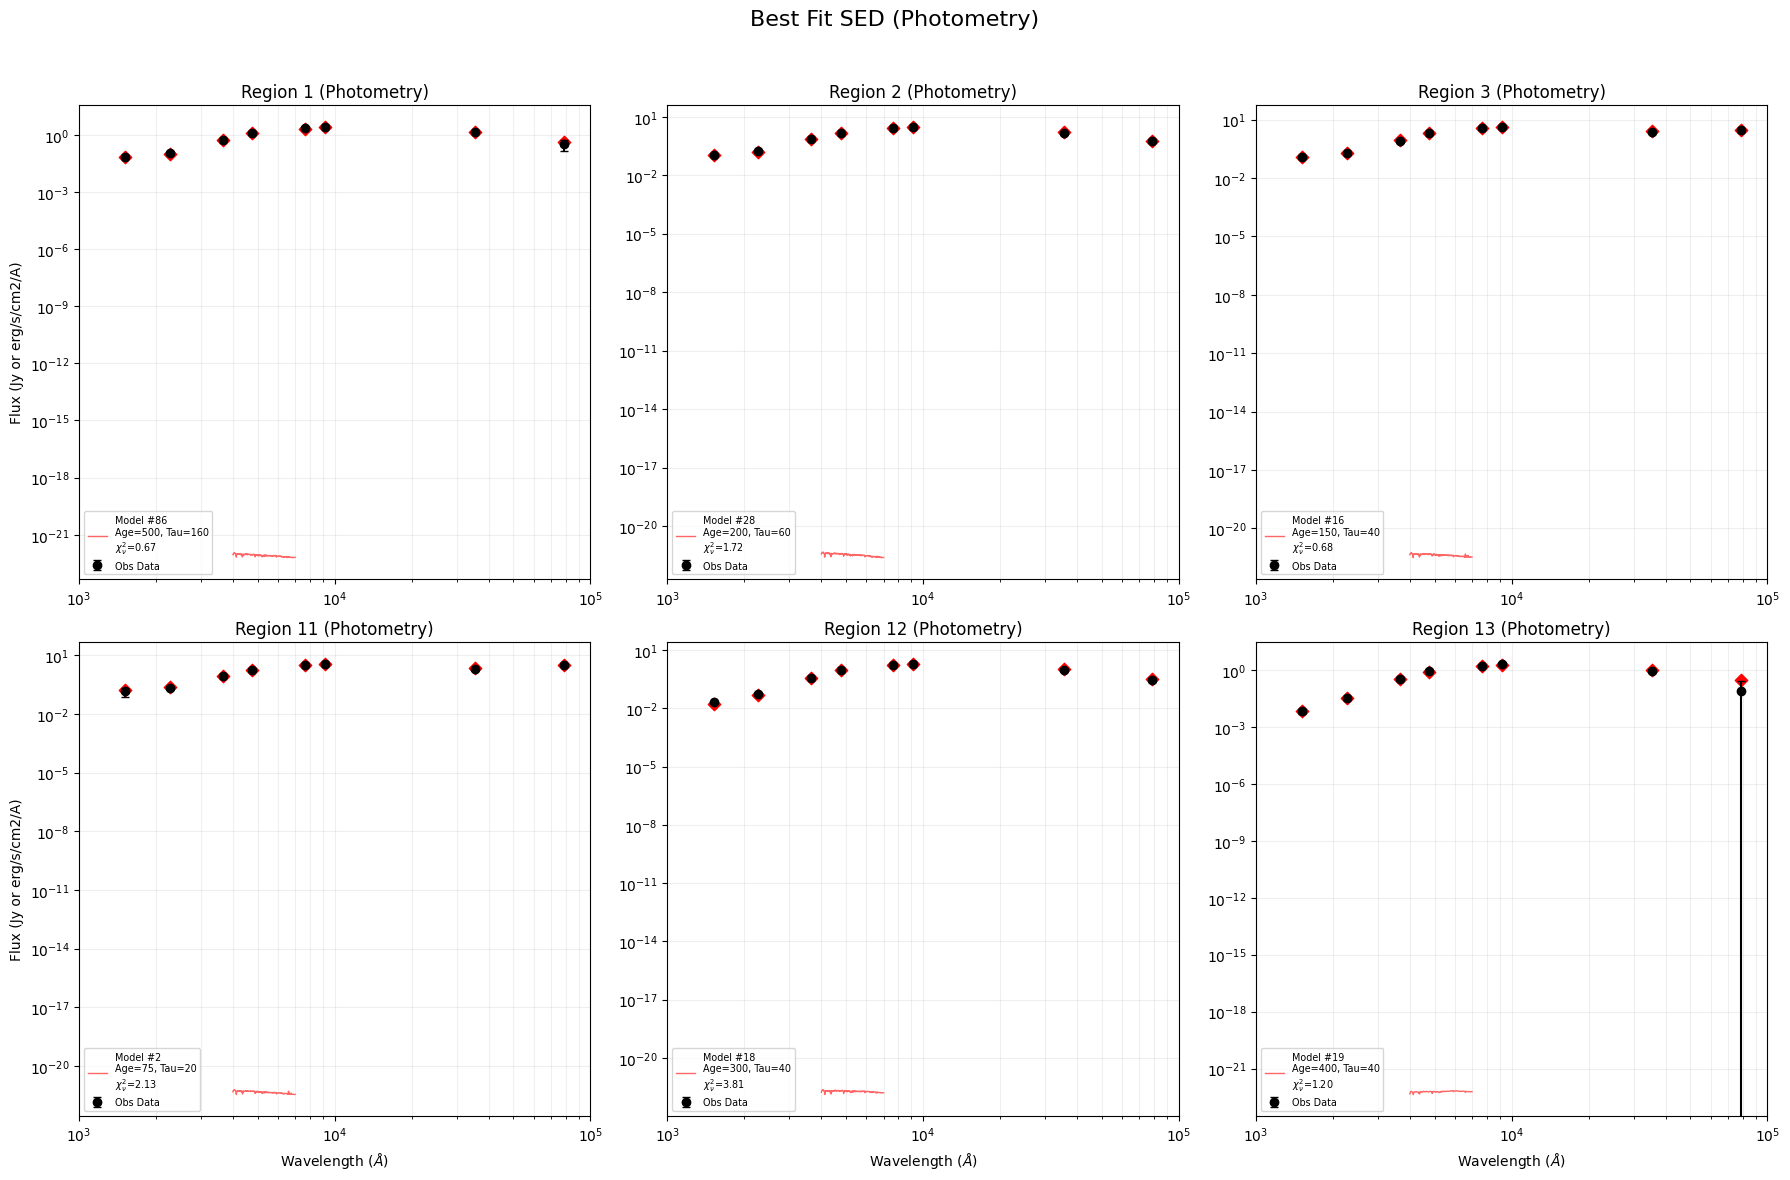

In [39]:
# --- 0. PREPARAZIONE DATI FOTOMETRICI -- # Definiamo le lunghezze d'onda efficaci (in Angstrom) per i filtri specificati.
# Nota: Questi sono valori indicativi standard (GALEX, SDSS/Johnson, Spitzer). 
# Se hai i valori esatti del tuo telescopio, aggiornali qui.
# Ordine: FUV, NUV, U, G, I, Z, IRAC1, IRAC4
filter_waves = np.array([1516, 2267, 3650, 4770, 7625, 9134, 35500, 78720])
filter_names = ['FUV', 'NUV', 'U', 'G', 'I', 'Z', 'IR1', 'IR4']

# Carichiamo il file di fotometria (Assumo che 'photo' sia il file FITS aperto)
# file_photo = 'TuoFileFotometria.fits'
# with fits.open(file_photo) as photo:
#     ... qui metti il tuo blocco di caricamento variabili flux_FUV etc ...

# PER IL TEST: Assumo che tu abbia già caricato queste variabili come nel tuo esempio:
# flux_FUV, err_FUV, flux_NUV, ... sono array lunghi quanto il numero di regioni.

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

regionid = [1, 2, 3, 11, 12, 13]

# Indici corrispondenti alle regioni nel file di fotometria 
# (Assumo che la riga 0 sia regione 1, riga 1 sia regione 2, etc. 
# Se non corrispondono, devi mappare regionid -> indice array)
#region_indices = [0, 1, 2, 10, 11, 12] 

for k, ax in enumerate(axes):
    #idx = region_indices[k] # Indice per estrarre il dato dagli array fotometrici
    idx = k
    reg_id = regionid[k]
    
    print(f"\n{'='*40}")
    print(f"--- ELABORAZIONE REGION {reg_id} (Fotometria) ---")

    # 1. COSTRUZIONE ARRAY DATI OSSERVATI
    # Creiamo un array unico per i flussi e gli errori della regione corrente
    obs_flux = np.array([
        flux_FUV[idx], flux_NUV[idx], 
        flux_U[idx],   flux_G[idx], 
        flux_I[idx],   flux_Z[idx], 
        flux_IRAC1[idx], flux_IRAC4[idx]
    ])
    
    obs_err = np.array([
        err_FUV[idx], err_NUV[idx], 
        err_U[idx],   err_G[idx], 
        err_I[idx],   err_Z[idx], 
        err_IRAC1[idx], err_IRAC4[idx]
    ])

    # Maschera per dati validi (escludiamo NaN, inf e flussi negativi/nulli se necessario)
    # Nota: In fotometria a volte i flussi sono negativi (rumore), ma per il fit SED logaritmico servono positivi.
    valid_mask = (obs_err > 0) & np.isfinite(obs_err) & (obs_flux > 0)
    
    # Calcolo flusso medio osservato (per normalizzazione)
    mean_obs = np.mean(obs_flux[valid_mask])

    # Plot Dati Osservati (Errorbar)
    ax.errorbar(filter_waves[valid_mask], obs_flux[valid_mask], yerr=obs_err[valid_mask], 
                fmt='o', color='black', label='Obs Data', capsize=3, zorder=10)

    # 2. CARICAMENTO MODELLI
    file_model = f'Models_N4330_region{reg_id}.fits'
    
    all_chi2 = []
    all_ages = []
    all_taus = []
    all_model_phot = [] # Salviamo la fotometria del modello
    all_model_fullspec = [] # (Opzionale) Se vuoi plottare anche lo spettro continuo sotto

    with fits.open(file_model) as modhdu:
        Next = modhdu[0].header['NEXT']
        # Se il file modelli contiene anche lo spettro continuo per estetica, carichiamo le onde
        modwave_full = modhdu[0].data.flatten()
        
        print(f"  > Trovati {Next} modelli...")

        for ext in np.arange(1, Next+1):
            thisext = modhdu[ext]
            thishead = thisext.header
            
            # Recupero parametri modello
            age = thishead['TRUNCAGE']
            tau = thishead['TRUNCTAU']

            # Recupero Fotometria del Modello dall'HEADER
            mod_phot_raw = np.array([
                thishead['MODFUV'], thishead['MODNUV'],
                thishead['MODU'],   thishead['MODG'],
                thishead['MODI'],   thishead['MODZ'],
                thishead['MODIR1'], thishead['MODIR4']
            ])
            
            # (Opzionale) Recupero spettro continuo raw per plot finale
            mod_spec_raw = thisext.data[0] 

            # Normalizzazione
            # Calcoliamo la media del modello SOLO sulle bande valide dei dati
            mean_model = np.mean(mod_phot_raw[valid_mask])
            
            if mean_model == 0 or np.isnan(mean_model):
                all_chi2.append(np.inf)
                all_ages.append(age)
                all_taus.append(tau)
                all_model_phot.append(mod_phot_raw)
                all_model_fullspec.append(mod_spec_raw)
                continue

            norm_factor = mean_obs / mean_model
            
            # Scaliamo la fotometria del modello
            mod_phot_scaled = mod_phot_raw * norm_factor
            
            # Calcolo Chi2 Pesato (SOLO sui punti fotometrici)
            # Formula: sum( (Obs - Mod)^2 / Err^2 )
            chi_terms = ((obs_flux[valid_mask] - mod_phot_scaled[valid_mask]) / obs_err[valid_mask])**2
            chi2 = np.sum(chi_terms)
            
            all_chi2.append(chi2)
            all_ages.append(age)
            all_taus.append(tau)
            all_model_phot.append(mod_phot_scaled)
            # Scaliamo anche lo spettro continuo per salvarlo
            all_model_fullspec.append(mod_spec_raw * norm_factor)

    # 3. TROVARE IL VINCITORE
    all_chi2 = np.array(all_chi2)
    min_idx = np.argmin(all_chi2)
    
    best_ext = min_idx + 1
    min_chi2 = all_chi2[min_idx]
    best_age = all_ages[min_idx]
    best_tau = all_taus[min_idx]
    
    best_phot_plot = all_model_phot[min_idx]
    best_spec_plot = all_model_fullspec[min_idx] # Lo spettro continuo corrispondente

    print(f"  > Best Fit: Ext #{best_ext}, Age={best_age:.0f}, Tau={best_tau:.0f}, Chi2={min_chi2:.2f}")

    # 4. PLOT DEL VINCITORE
    n_points = np.sum(valid_mask)
    dof = n_points - 2 # Gradi di libertà
    red_chi2 = min_chi2 / dof if dof > 0 else min_chi2

    label_str = (f'Model #{best_ext}\n'
                 f'Age={best_age:.0f}, Tau={best_tau:.0f}\n'
                 f'$\chi^2_\\nu$={red_chi2:.2f}')

    # A. Plot dei Punti Fotometrici del Modello (Diamanti rossi)
    ax.scatter(filter_waves, best_phot_plot, color='red', marker='D', s=40, zorder=5)
    
    # B. Plot dello Spettro Continuo del Modello (Linea rossa sottile)
    # Questo aiuta visivamente a capire l'andamento della SED
    ax.plot(modwave_full, best_spec_plot, color='red', alpha=0.6, linewidth=1, label=label_str)

    # Cosmetica
    ax.set_title(f'Region {reg_id} (Photometry)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    # Impostiamo i limiti degli assi per vedere bene i dati
    ax.set_xlim(1000, 100000) # Da 1000 Angstrom a 10 micron
    
    if k >= 3: ax.set_xlabel('Wavelength ($\AA$)')
    if k % 3 == 0: ax.set_ylabel('Flux (Jy or erg/s/cm2/A)')
    
    ax.legend(fontsize='x-small', loc='best')

plt.suptitle('Best Fit SED (Photometry)', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


--- FIT FOTOMETRICO REGION 1 ---
  > Testando 110 modelli (confronto fotometrico)...
  > Best Fit: Ext #86
  > Age=500 Myr, Tau=160 Myr, Chi2=4.05

--- FIT FOTOMETRICO REGION 2 ---
  > Testando 110 modelli (confronto fotometrico)...
  > Best Fit: Ext #28
  > Age=200 Myr, Tau=60 Myr, Chi2=10.33

--- FIT FOTOMETRICO REGION 3 ---
  > Testando 110 modelli (confronto fotometrico)...
  > Best Fit: Ext #16
  > Age=150 Myr, Tau=40 Myr, Chi2=4.08

--- FIT FOTOMETRICO REGION 11 ---
  > Testando 110 modelli (confronto fotometrico)...
  > Best Fit: Ext #2
  > Age=75 Myr, Tau=20 Myr, Chi2=12.80

--- FIT FOTOMETRICO REGION 12 ---
  > Testando 110 modelli (confronto fotometrico)...
  > Best Fit: Ext #18
  > Age=300 Myr, Tau=40 Myr, Chi2=22.86

--- FIT FOTOMETRICO REGION 13 ---
  > Testando 110 modelli (confronto fotometrico)...
  > Best Fit: Ext #19
  > Age=400 Myr, Tau=40 Myr, Chi2=7.18


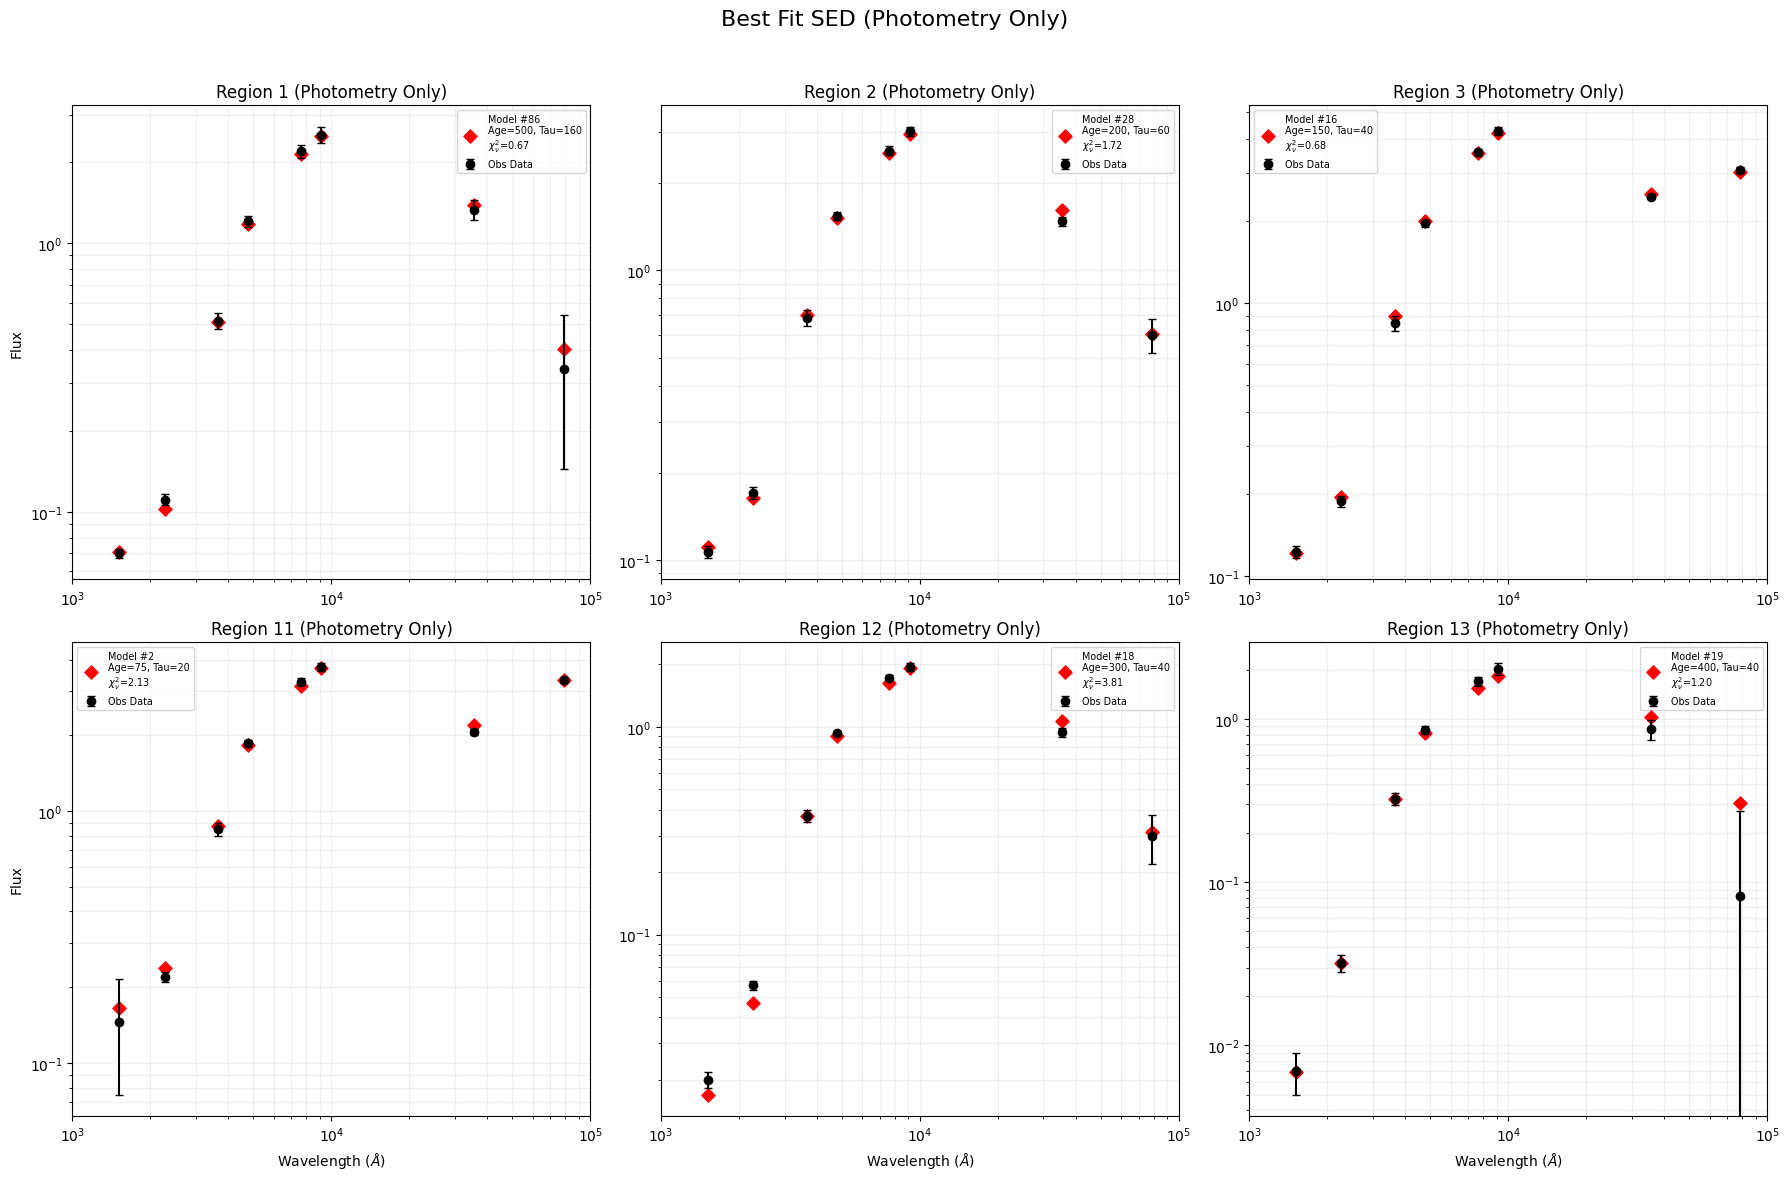

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# --- 0. DEFINIZIONE FILTRI ---
# Lunghezze d'onda efficaci (Angstrom) per FUV, NUV, U, G, I, Z, IRAC1, IRAC4
filter_waves = np.array([1516, 2267, 3650, 4770, 7625, 9134, 35500, 78720])

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# ID delle regioni da analizzare
regionid = [1, 2, 3, 11, 12, 13]

for k, ax in enumerate(axes):
    # Usa 'k' come indice per scorrere gli array di flusso (0, 1, 2, 3, 4, 5)
    # Assumendo che i tuoi array (es. flux_FUV) contengano già solo queste 6 regioni.
    idx = k  
    reg_id = regionid[k]
    
    print(f"\n{'='*40}")
    print(f"--- FIT FOTOMETRICO REGION {reg_id} ---")

    # 1. COSTRUZIONE ARRAY DATI OSSERVATI
    # Creiamo un array unico di 8 elementi per questa specifica regione
    obs_flux = np.array([
        flux_FUV[idx], flux_NUV[idx], 
        flux_U[idx],   flux_G[idx], 
        flux_I[idx],   flux_Z[idx], 
        flux_IRAC1[idx], flux_IRAC4[idx]
    ])
    
    obs_err = np.array([
        err_FUV[idx], err_NUV[idx], 
        err_U[idx],   err_G[idx], 
        err_I[idx],   err_Z[idx], 
        err_IRAC1[idx], err_IRAC4[idx]
    ])

    # Maschera: usiamo solo i punti con dati validi (errori finiti e flussi positivi)
    valid_mask = (obs_err > 0) & np.isfinite(obs_err) & (obs_flux > 0)
    
    if np.sum(valid_mask) == 0:
        print("  ! Nessun punto valido per questa regione. Salto.")
        continue

    # Calcolo flusso medio osservato (servirà per normalizzare i modelli)
    mean_obs = np.mean(obs_flux[valid_mask])

    # Plot dei punti osservati (con barre d'errore)
    ax.errorbar(filter_waves[valid_mask], obs_flux[valid_mask], yerr=obs_err[valid_mask], 
                fmt='ko', label='Obs Data', capsize=3, zorder=10)

    # 2. CARICAMENTO MODELLI (SOLO FOTOMETRIA DAGLI HEADER)
    file_model = f'Models_N4330_region{reg_id}.fits'
    
    all_chi2 = []
    all_ages = []
    all_taus = []
    all_model_phot = [] 

    with fits.open(file_model) as modhdu:
        Next = modhdu[0].header['NEXT']
        print(f"  > Testando {Next} modelli (confronto fotometrico)...")

        for ext in np.arange(1, Next+1):
            thishead = modhdu[ext].header
            
            # Parametri del modello
            age = thishead['TRUNCAGE']
            tau = thishead['TRUNCTAU']
            
            # COSTRUZIONE ARRAY FOTOMETRIA SINTETICA (DALL'HEADER)
            mod_phot_raw = np.array([
                thishead['MODFUV'], thishead['MODNUV'],
                thishead['MODU'],   thishead['MODG'],
                thishead['MODI'],   thishead['MODZ'],
                thishead['MODIR1'], thishead['MODIR4']
            ])
            
            # Normalizzazione: scaliamo il modello sulla media dei dati osservati
            mean_model = np.mean(mod_phot_raw[valid_mask])
            
            if mean_model <= 0 or np.isnan(mean_model):
                # Se il modello non valido, salviamo valori fittizi (infinito)
                all_chi2.append(np.inf)
                all_ages.append(age)
                all_taus.append(tau)
                all_model_phot.append(mod_phot_raw)
                continue

            norm_factor = mean_obs / mean_model
            mod_phot_scaled = mod_phot_raw * norm_factor
            
            # Calcolo CHI-QUADRO (Solo sui punti fotometrici validi)
            chi_terms = ((obs_flux[valid_mask] - mod_phot_scaled[valid_mask]) / obs_err[valid_mask])**2
            chi2 = np.sum(chi_terms)
            
            # Salvataggio risultati
            all_chi2.append(chi2)
            all_ages.append(age)
            all_taus.append(tau)
            all_model_phot.append(mod_phot_scaled)

    # 3. SELEZIONE VINCITORE
    all_chi2 = np.array(all_chi2)
    min_idx = np.argmin(all_chi2)
    
    best_ext = min_idx + 1 # Estensione FITS (parte da 1)
    min_chi2 = all_chi2[min_idx]
    best_age = all_ages[min_idx]
    best_tau = all_taus[min_idx]
    best_phot_plot = all_model_phot[min_idx]

    print(f"  > Best Fit: Ext #{best_ext}")
    print(f"  > Age={best_age:.0f} Myr, Tau={best_tau:.0f} Myr, Chi2={min_chi2:.2f}")

    # 4. PLOT DEL VINCITORE
    # Calcolo Chi2 ridotto per la legenda
    n_points = np.sum(valid_mask)
    dof = n_points - 2
    red_chi2 = min_chi2 / dof if dof > 0 else min_chi2

    label_str = (f'Model #{best_ext}\n'
                 f'Age={best_age:.0f}, Tau={best_tau:.0f}\n'
                 f'$\chi^2_\\nu$={red_chi2:.2f}')

    # Plot dei punti del modello (Diamanti Rossi)
    ax.scatter(filter_waves, best_phot_plot, color='red', marker='D', s=45, label=label_str, zorder=9)
    
    # Cosmetica del grafico
    ax.set_title(f'Region {reg_id} (Photometry Only)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    # Limiti assi per vedere bene tutto lo spettro fotometrico (da UV a IR)
    ax.set_xlim(1000, 100000) 
    
    if k >= 3: ax.set_xlabel('Wavelength ($\AA$)')
    if k % 3 == 0: ax.set_ylabel('Flux')
    
    ax.legend(fontsize='x-small', loc='best')

plt.suptitle('Best Fit SED (Photometry Only)', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()